First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Shape: (1025, 14)

===== Decision Tree =====
Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
wei

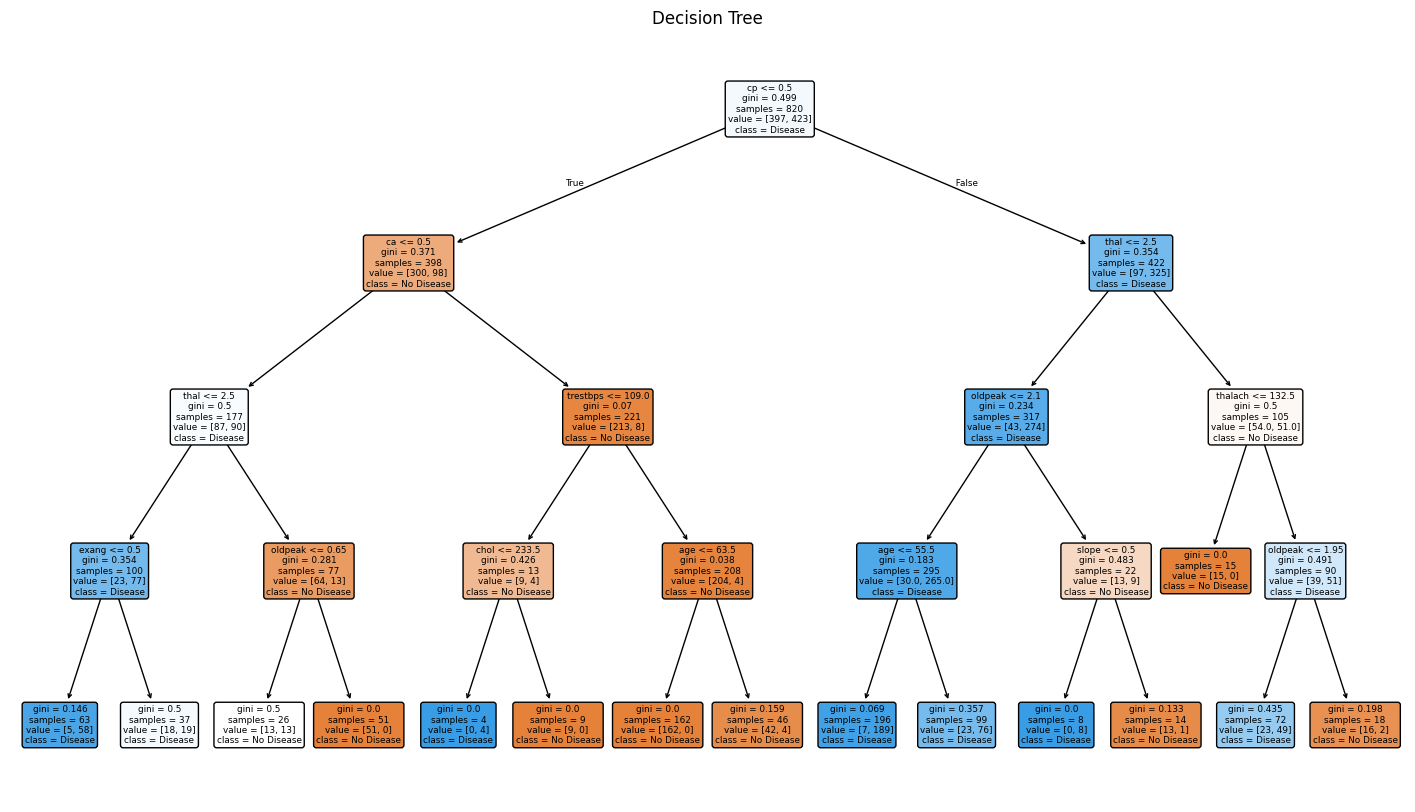


===== Random Forest =====
Accuracy: 0.9853658536585366

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Confusion Matrix:
[[102   0]
 [  3 100]]

Feature Importance:
     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


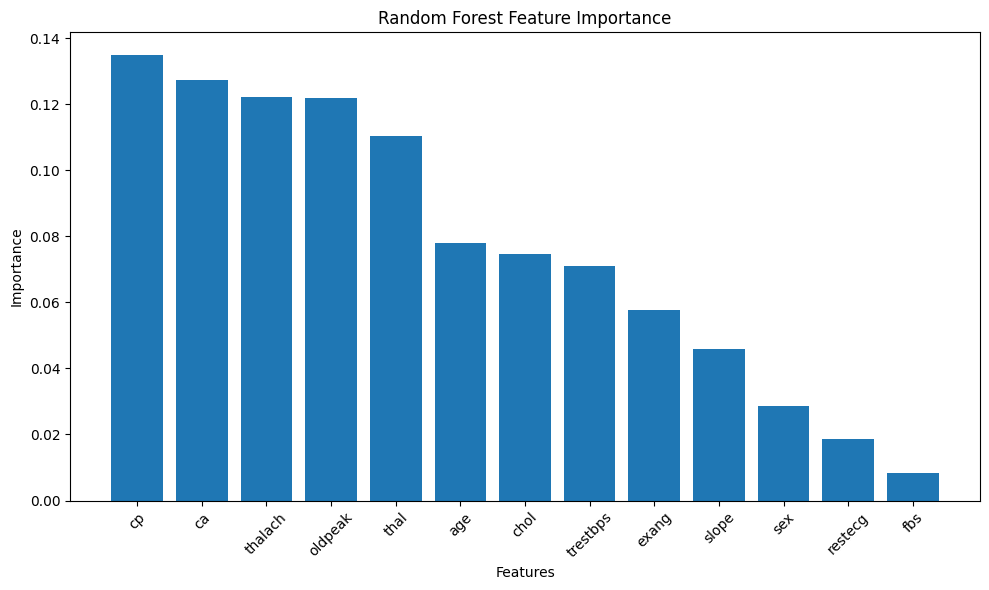


Cross Validation Scores: [1.         1.         1.         1.         0.98536585]
Average Cross Validation Accuracy: 0.9970731707317073


In [1]:
# ==========================================
# Decision Tree and Random Forest Classifier
# Heart Disease Dataset
# ==========================================

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------
# Load Dataset
# ------------------------------------------
df = pd.read_csv("heart.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

# ------------------------------------------
# Separate Features and Target
# ------------------------------------------
X = df.drop("target", axis=1)
y = df["target"]

# ------------------------------------------
# Split Dataset
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# Decision Tree Model
# ------------------------------------------
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\n===== Decision Tree =====")
print("Accuracy:", accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

# ------------------------------------------
# Visualize Decision Tree
# ------------------------------------------
plt.figure(figsize=(18,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree")
plt.show()

# ------------------------------------------
# Random Forest Model
# ------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# ------------------------------------------
# Feature Importance
# ------------------------------------------
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

# ------------------------------------------
# Cross Validation
# ------------------------------------------
scores = cross_val_score(rf, X, y, cv=5)

print("\nCross Validation Scores:", scores)
print("Average Cross Validation Accuracy:", scores.mean())